# ADS 508 Final Team Project

# Nutri Access Analytics

## Group 3: James Shoenhair, Shery Thaker, and Nancy Walker 

## Introduction 

The goal of this project is to develop a data pipeline and analytical workflow for a hypothetical company focused on improving public health outcomes through data-driven decision-making. This company aims to identify patterns in food access, socioeconomic conditions, and health outcomes to better understand and address disparities across California counties.

To support this objective, a MySQL-based data pipeline was designed to ingest, clean, and integrate multiple public datasets, including the USDA Food Environment Atlas, CDC PLACES dataset, U.S. Census data, and geospatial retail food location data. The pipeline leverages AWS S3 for data storage and processing, producing structured datasets for analysis.

### Research Questions:

    - Which communities exhibit characteristics associated with limited access to healthy food resources (i.e., potential food deserts)?

    - How do demographic and socioeconomic factors vary across communities with different levels of food access?

    - Can food environment, demographic, and health-related features be used to predict communities at high risk of limited food access?

    - How do geographic patterns of food access and retail food availability vary across counties, particularly within California?


In [2]:
import pandas as pd
import numpy
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
!pip install geopandas
import geopandas as gpd

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached pyogrio-0.12.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (5.9 kB)
  Using cached pyproj-3.7.2-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached pyogrio-0.12.1-cp311-cp311-manylinux_2_28_x86_64.whl (32.5 MB)
Using cached pyproj-3.7.2-cp311-cp311-manylinux_2_28_x86_64.whl (9.5 MB)
Using cached shapely-2.1.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.1 MB)


## S3 setup 

This notebook uses processed datasets stored in Amazon S3. These files were created by the project pipeline, which downloads raw data from S3, preprocesses the datasets, saves outputs locally, and uploads cleaned outputs back to S3 under the processedData/ prefix.

In [3]:
bucket = os.getenv("S3_BUCKET", "nutriaccess-data")
processed_prefix = "processedData/"

## Load processed files from S3

Pipeline writes ingested data outputs back to S3

In [4]:
food_access = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_access_clean.csv")
places = pd.read_csv(f"s3://{bucket}/{processed_prefix}places_ca_health_clean.csv")
food_env = pd.read_csv(f"s3://{bucket}/{processed_prefix}food_environment_clean.csv")
retail_food = pd.read_csv(f"s3://{bucket}/{processed_prefix}california_food_store_locations.csv")
gdf = gpd.read_file(f"s3://{bucket}/{processed_prefix}california_food_store_locations.geojson")

## EDA

### food_access

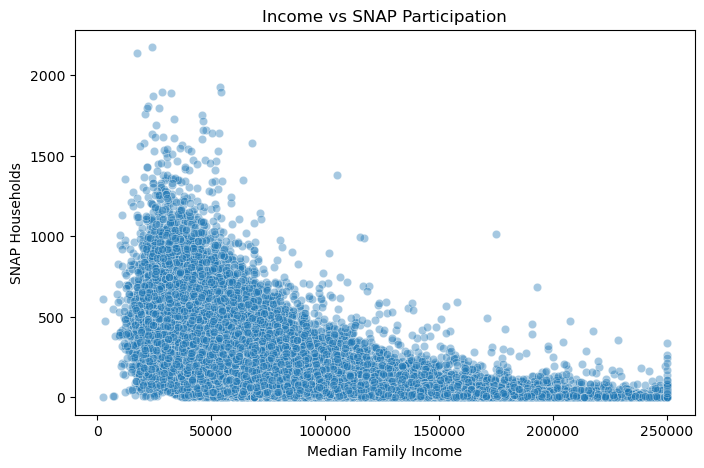

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=food_access,
    x='MedianFamilyIncome',
    y='TractSNAP',
    alpha=0.4
)

plt.title('Income vs SNAP Participation')
plt.xlabel('Median Family Income')
plt.ylabel('SNAP Households')
plt.show()

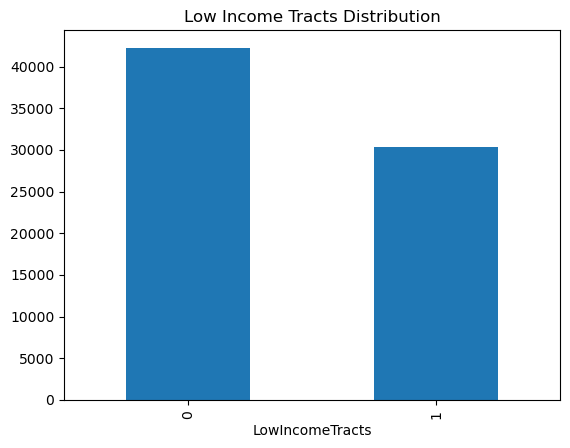

In [7]:
food_access['LowIncomeTracts'].value_counts().plot(kind='bar')
plt.title('Low Income Tracts Distribution')
plt.show()

### PLACES

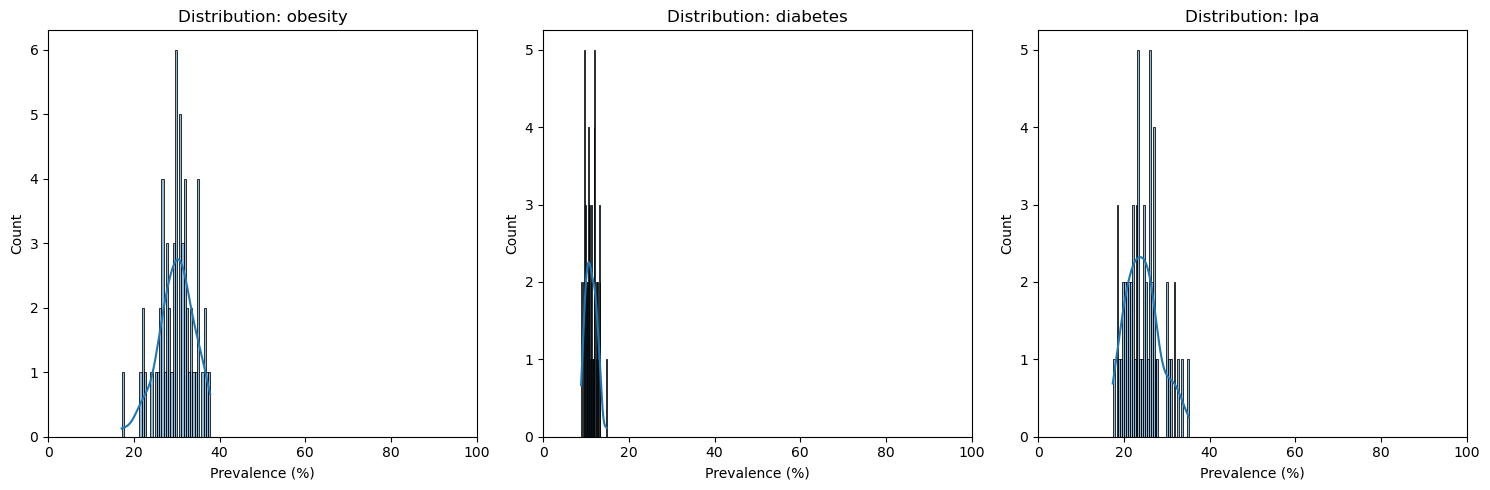

In [8]:
# Distribution of key health metrics

health_measures = ['obesity', 'diabetes', 'lpa']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, measure in zip(axes, health_measures):
    data = places[measure].dropna()
    sns.histplot(data, bins=40, kde=True, ax=ax)
    ax.set_title(f'Distribution: {measure}')
    ax.set_xlabel('Prevalence (%)')
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [9]:
# California-focused analysis
print(places.columns.tolist())
print(places.head())

ca_places = places.copy()

['stateabbr', 'county_name', 'bphigh', 'csmoking', 'diabetes', 'lpa', 'obesity']
  stateabbr county_name  bphigh  csmoking  diabetes    lpa  obesity
0        CA     Alameda   27.50      9.25     10.55  20.35    22.65
1        CA      Alpine   31.80     11.30     10.05  18.70    28.55
2        CA      Amador   33.45     12.30     10.20  21.60    29.55
3        CA       Butte   31.35     13.35     10.30  22.75    29.95
4        CA   Calaveras   33.00     13.65     11.15  23.50    29.80


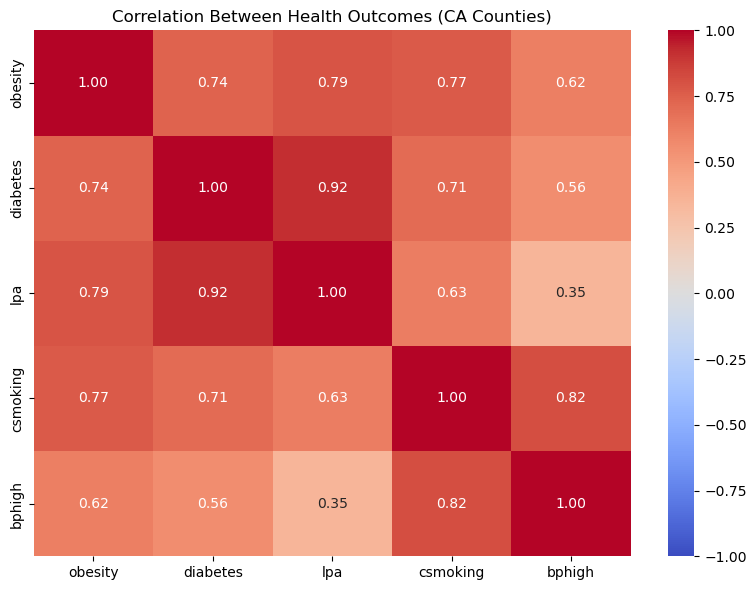

In [10]:
focus = ['obesity', 'diabetes', 'lpa', 'csmoking', 'bphigh']

plt.figure(figsize=(8, 6))
sns.heatmap(
    places[focus].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Health Outcomes (CA Counties)")
plt.tight_layout()
plt.show()

### food_env

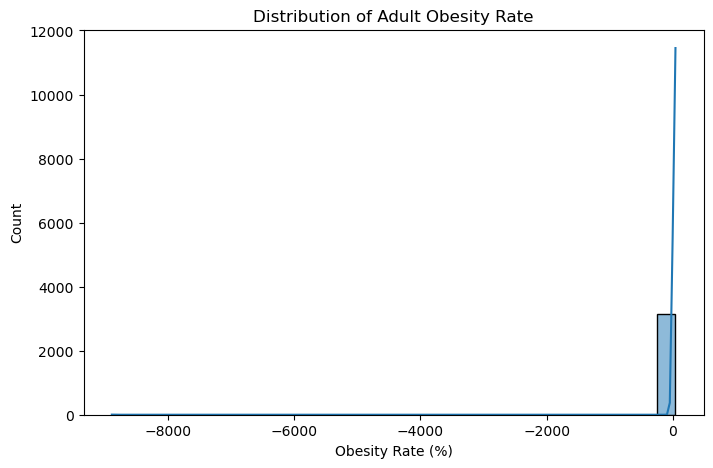

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(food_env['pct_obese_adults22'].dropna(), bins=30, kde=True)
plt.title('Distribution of Adult Obesity Rate')
plt.xlabel('Obesity Rate (%)')
plt.show()

<Axes: xlabel='povrate21', ylabel='pct_diabetes_adults19'>

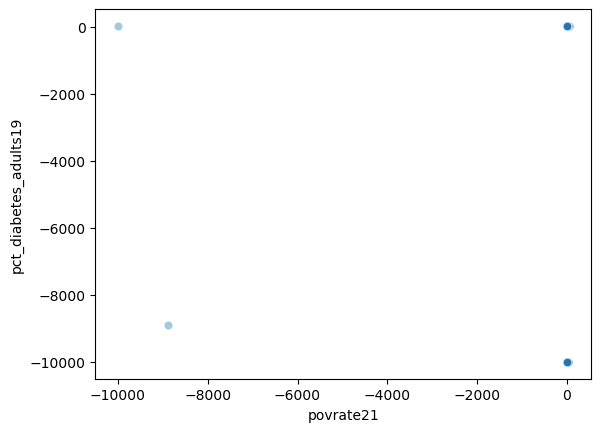

In [13]:
sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_diabetes_adults19',
    alpha=0.4
)

In [14]:
### retail_food

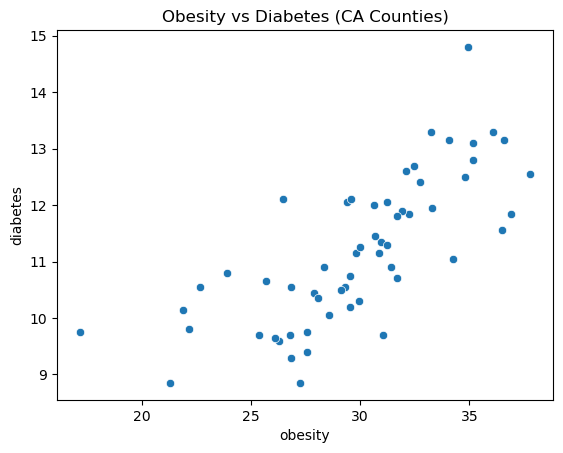

In [15]:
sns.scatterplot(
    data=ca_places,
    x='obesity',
    y='diabetes'
)
plt.title("Obesity vs Diabetes (CA Counties)")
plt.show()

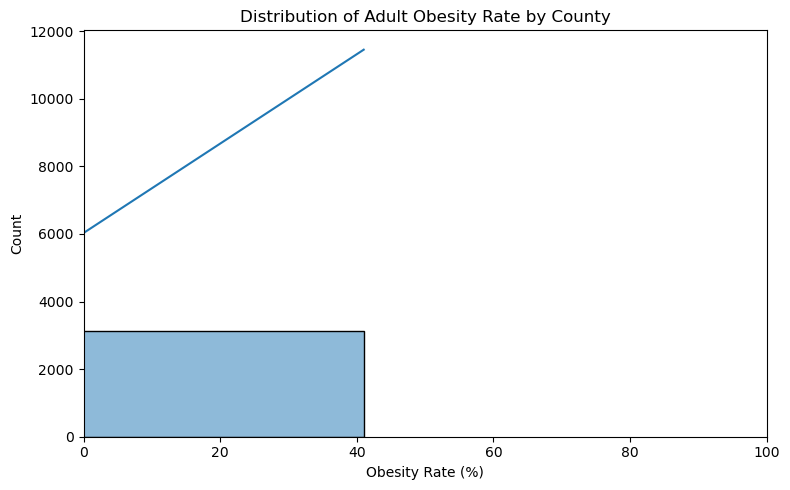

In [16]:
# Obesity Distribution

plt.figure(figsize=(8, 5))
sns.histplot(food_env['pct_obese_adults22'].dropna(), bins=30, kde=True)

plt.title('Distribution of Adult Obesity Rate by County')
plt.xlabel('Obesity Rate (%)')
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

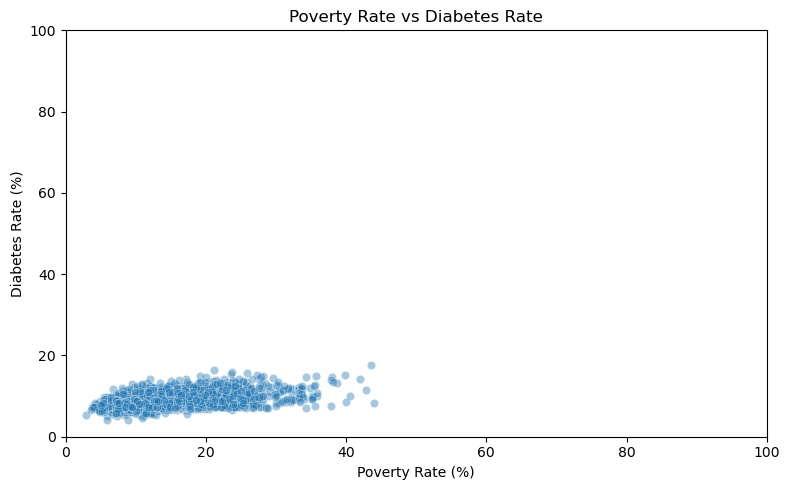

In [17]:
# Poverty vs Diabetes Scatter

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_diabetes_adults19',
    alpha=0.4
)

plt.title('Poverty Rate vs Diabetes Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Diabetes Rate (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

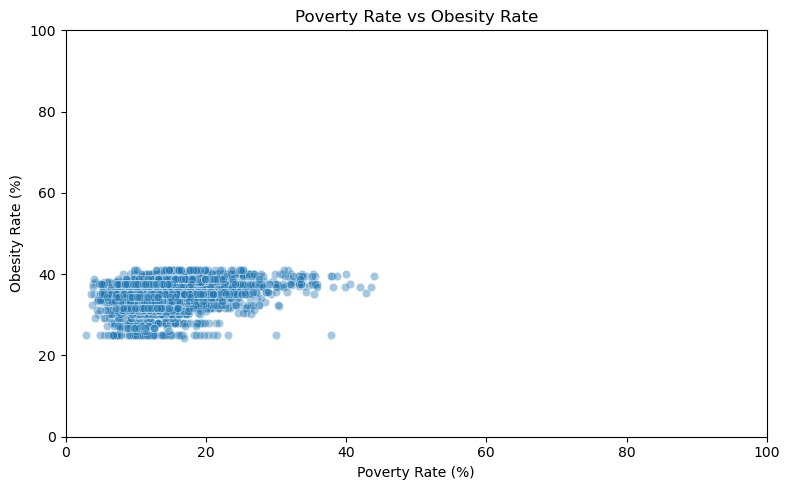

In [18]:
# Obesity vs Poverty

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=food_env,
    x='povrate21',
    y='pct_obese_adults22',
    alpha=0.4
)

plt.title('Poverty Rate vs Obesity Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Obesity Rate (%)')
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

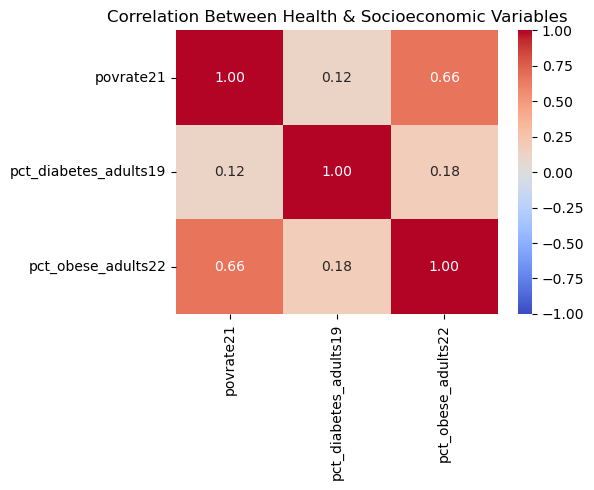

In [19]:
# Correlation Heatmap

cols = [
    'povrate21',
    'pct_diabetes_adults19',
    'pct_obese_adults22'
]

plt.figure(figsize=(6, 5))

sns.heatmap(
    food_env[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Between Health & Socioeconomic Variables')
plt.tight_layout()
plt.show()

### GIS 

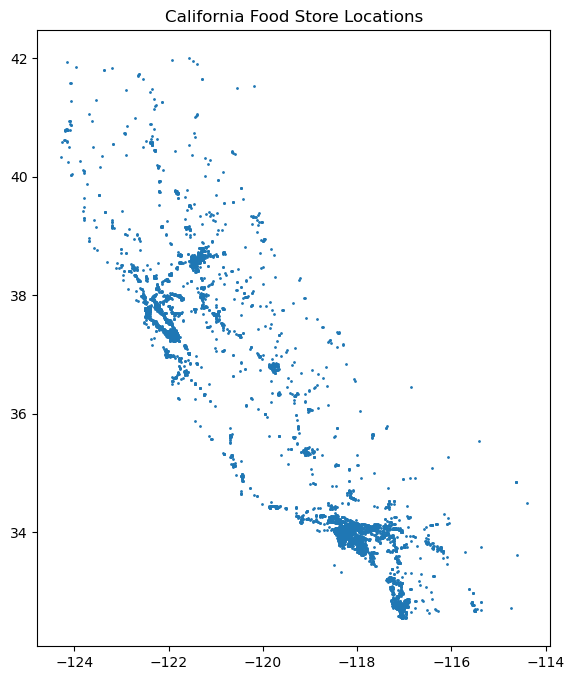

In [21]:
gdf.plot(figsize=(8,8), markersize=1)
plt.title("California Food Store Locations")
plt.show()

## Feature Selection 

Datasets were merged at the county level to create a unified modeling dataset. Food environment data served as the base, and additional features such as health outcomes from the PLACES dataset and socioeconomic variables from Census data were incorporated. Datasets with different granularities, such as tract-level food access data, are useful for exploratory analysis but maynot be useful in the final model due to aggregation constraints.

From:

food_env → poverty, obesity, diabetes

places → smoking, BP, inactivity

census → income, demographics

retail_food → store counts (aggregated)

### Standardize keys

In [22]:
food_env['county_name'] = food_env['county'].str.lower().str.strip()
places['county_name'] = places['county_name'].str.lower().str.strip()

### Merging Check 

In [24]:
preview_merge = food_env.merge(
    places,
    on='county_name',
    how='inner'
)

print(preview_merge.shape)

(85, 12)


## Modeling Prep